# KNN으로 포지션 예측하기

In [55]:
# Random값을 정하기
import numpy as np
np.random.seed(5)

In [56]:
import pandas as pd

In [57]:
train = pd.read_csv("../Data/basketball_train.csv")
test = pd.read_csv("../Data/basketball_test.csv")

In [58]:
train.head()

,Player,Pos,3P,TRB,BLK
0,Wayne Ellington,SG,2.4,2.1,0.1
1,Buddy Hield,SG,1.8,3.3,0.1
2,Avery Bradley,SG,2.0,6.1,0.2
3,Edy Tavares,C,0.0,5.5,3.0
4,Kentavious Caldwell-Pope,SG,2.0,3.3,0.2


In [59]:
test.head()


,Player,Pos,3P,TRB,BLK
0,Willie Reed,C,0.0,4.7,0.7
1,Kyle Korver,SG,2.4,2.8,0.3
2,Marc Gasol,C,1.4,6.3,1.3
3,Alex Abrines,SG,1.4,1.3,0.1
4,Klay Thompson,SG,3.4,3.7,0.5


In [60]:
print(train.shape)
print(train.count())
print(train.isnull().sum())

(80, 5)
Player    80
Pos       80
3P        80
TRB       80
BLK       80
dtype: int64
Player    0
Pos       0
3P        0
TRB       0
BLK       0
dtype: int64


In [61]:
print(test.shape)
print(test.count())
print(test.isnull().sum())

(20, 5)
Player    20
Pos       20
3P        20
TRB       20
BLK       20
dtype: int64
Player    0
Pos       0
3P        0
TRB       0
BLK       0
dtype: int64


### 최적의 k 찾기 (교차검증 - cross validation)

In [62]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score # 교차검증

In [63]:
# 최적의 k를 찾기 위해 교차 검증을 수행할 k의 점위를 3부터 학습데이터의 절반까지 지정
max_k_range = train.shape[0] // 2
max_k_range

40

In [64]:
# 최적의 k를 찾기 위한 범위 확인
k_list = []
for i in range(3, max_k_range, 2):
    k_list.append(i)

k_list

[3, 5, 7, 9, 11, 13, 15, 17, 19, 21, 23, 25, 27, 29, 31, 33, 35, 37, 39]

In [65]:
# 점수 및 Train Data 정의
cross_validation_scores = []
x_train = train[['3P', 'BLK', 'TRB']]
y_train = train['Pos']

print(x_train.head())
print(y_train.head())

    3P  BLK  TRB
0  2.4  0.1  2.1
1  1.8  0.1  3.3
2  2.0  0.2  6.1
3  0.0  3.0  5.5
4  2.0  0.2  3.3
0    SG
1    SG
2    SG
3     C
4    SG
Name: Pos, dtype: object


In [66]:
# 교차검증(10-fold)를 각 k를 대상으로 수행해 검증 결과를 저장
# 10번 테스트

for k in k_list:
  knn = KNeighborsClassifier(n_neighbors=k)
  scores = cross_val_score(
    knn, # 모델 이름
    # 각각의 score 낼 필요 없이 cross_val_score 가 해줌
    x_train,
    y_train,
    cv=10, # cross validation(교차검증 횟수)
    scoring='accuracy'

  )
  cross_validation_scores.append(scores.mean())

cross_validation_scores

[0.9125,
 0.8875,
 0.9125,
 0.925,
 0.925,
 0.9,
 0.9,
 0.8875,
 0.9,
 0.875,
 0.875,
 0.875,
 0.875,
 0.8625,
 0.85,
 0.85,
 0.85,
 0.85,
 0.8375]

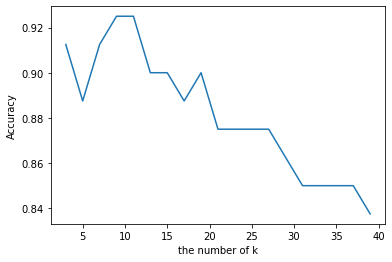

In [67]:
# k에 따른 정확도를 시각화
import matplotlib.pyplot as plt

plt.plot(k_list, cross_validation_scores)
plt.xlabel('the number of k')
plt.ylabel('Accuracy')
plt.show()

In [68]:
# 가장 예측율이 높은 k를 선정
cvs = cross_validation_scores
k_list[cvs.index(max(cross_validation_scores))]
print("The best number of k is", k)

The best number of k is 39


---
### 2개의 특징으로 예측하기 (3점슛, 블로킹)

In [69]:
from sklearn.neighbors import KNeighborsClassifier

In [70]:
knn = KNeighborsClassifier(n_neighbors=k)

In [71]:
# 학습에 사용할 features
x_train = train[['3P','BLK']]

In [72]:
# 학습에 사용할 target
y_train = train['Pos']

In [73]:
# 학습시키기
knn.fit(x_train, y_train)

KNeighborsClassifier(n_neighbors=39)

In [74]:
# 검증에 사용할 features
x_test = test[['3P','BLK']]


In [75]:
# 검증의 정답
y_test = test['Pos']

In [77]:
knn.score(x_test, y_test)

0.9

In [78]:
# 예측 
pred = knn.predict(x_test)
pred

array(['C', 'SG', 'SG', 'SG', 'SG', 'SG', 'SG', 'SG', 'SG', 'SG', 'C',
       'SG', 'C', 'C', 'C', 'SG', 'SG', 'C', 'C', 'C'], dtype=object)

In [80]:
# 실제값과 예측값으 비교
comparison = pd.DataFrame(
    {'예측값': pred,
    '정답': y_test}
)
comparison.head()

,예측값,정답
0,C,C
1,SG,SG
2,SG,C
3,SG,SG
4,SG,SG


### Confusion matrix

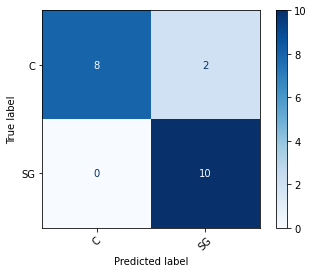

In [84]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

confusion_matrix = confusion_matrix(y_test, pred)
target_names = ['C','SG']
disp = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix,
    display_labels=target_names
)
disp.plot(
    cmap=plt.cm.Blues,
    xticks_rotation=45

)

plt.show()

---
### 3개의 특징으로 예측하기 (3점슛, 블로킹, 리바운드)

In [ ]:
3P : 3.4
BLK : 0.5
TRB : 3.7

In [85]:
train.head()

,Player,Pos,3P,TRB,BLK
0,Wayne Ellington,SG,2.4,2.1,0.1
1,Buddy Hield,SG,1.8,3.3,0.1
2,Avery Bradley,SG,2.0,6.1,0.2
3,Edy Tavares,C,0.0,5.5,3.0
4,Kentavious Caldwell-Pope,SG,2.0,3.3,0.2


In [87]:
# 학습에 사용할 features
x_train = train[['3P','BLK','TRB']]
y_train = train['Pos']

In [88]:
# test

x_test = test[['3P','BLK','TRB']]
y_test = test['Pos']

In [90]:
# 학습시키기
knn.fit(x_train, y_train)

# 검증하기
knn.score(x_test, y_test)

0.8

In [91]:
# 검증의 정답
pred = knn.predict(x_test)
pred

array(['C', 'SG', 'C', 'SG', 'SG', 'SG', 'SG', 'SG', 'C', 'C', 'SG', 'SG',
       'SG', 'C', 'C', 'SG', 'SG', 'C', 'C', 'SG'], dtype=object)

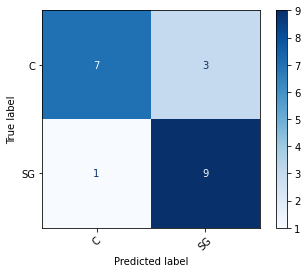

In [93]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

confusion_matrix = confusion_matrix(y_test, pred)
target_names = ['C','SG']
disp = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix,
    display_labels=target_names
)
disp.plot(
    cmap=plt.cm.Blues,
    xticks_rotation=45

)

plt.show()

In [96]:
print(knn.predict([['3.4','0.5','3.7']]))

['SG']


/Users/tj/opt/anaconda3/lib/python3.9/site-packages/sklearn/utils/validation.py:63: FutureWarning: Arrays of bytes/strings is being converted to decimal numbers if dtype='numeric'. This behavior is deprecated in 0.24 and will be removed in 1.1 (renaming of 0.26). Please convert your data to numeric values explicitly instead.
  return f(*args, **kwargs)
